In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import pandas as pd
import warnings
import ast
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.metrics import mean_squared_error
from sklearn.decomposition import PCA

# ==========================================================================
# CONFIGURATION
# ==========================================================================
TEST_SIZE = 0.1
RANDOM_SEED = 42

# CACHE SETTINGS
CACHE_FILE = 'pca_aggregate_survey_cache.pkl'

# MODEL
K_MODEL = 30
USE_PCA = True  # Set to False to use raw embeddings instead of PCA
PCA_COMPONENTS = 48  # Only used if USE_PCA is True

# SPARSITY
LAMBDA_TAU = 0.002
TAU_INIT = 0.5
TAU_WARMUP = 200
RAMP_EPOCHS = 200
SNAPPING_THRESHOLD = 0.005
DEAD_ZONE_VALUE = -0.1
TAU_THRESHOLD = 0.01

# TRAINING
EPOCHS = 1000
EVAL_EVERY = 100  # Reduced frequency to speed up multi-run
PATIENCE = 30
MIN_DELTA = 1e-6

# OPTIMIZATION
LR_THETA = 0.02
LR_GLOBAL = 0.005
WD_THETA = 1e-3
WD_W = 1e-5

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")

# Device setup - Force CPU to avoid CUDA errors
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f"Using device: {device}")

Using device: cuda


In [2]:

# ==========================================================================
# UTILITY FUNCTIONS
# ==========================================================================
def load_cache():
    """Load cached results from disk."""
    if os.path.exists(CACHE_FILE):
        print(f"Loading cache from {CACHE_FILE}...")
        with open(CACHE_FILE, 'rb') as f:
            return pickle.load(f)
    return {}

def save_cache(cache):
    """Save cached results to disk."""
    with open(CACHE_FILE, 'wb') as f:
        pickle.dump(cache, f)
    print(f"Cache saved to {CACHE_FILE}")

def compute_rmse(predictions, targets, mask):
    valid = mask.astype(bool) if isinstance(mask, np.ndarray) else mask
    return np.sqrt(mean_squared_error(targets[valid], predictions[valid]))

def trainer(parameters, optim, closure, n_iter=100, verbose=False):
    """Training loop with convergence criteria similar to calibration (1).ipynb"""
    for iteration in range(n_iter):
        if iteration > 0:
            previous_parameters = [p.clone() for p in parameters]
            previous_loss = loss.clone()
        
        loss = optim.step(closure)
        
        if iteration > 0:
            d_loss = (previous_loss - loss).item()
            d_parameters = sum(
                torch.norm(prev - curr, p=2).item()
                for prev, curr in zip(previous_parameters, parameters)
            )
            grad_norm = sum(torch.norm(p.grad, p=2).item() for p in parameters if p.grad is not None)
            
            if d_loss < 1e-5 and d_parameters < 1e-5 and grad_norm < 1e-5:
                break
    return parameters

class ReluARDModel(nn.Module):
    def __init__(self, N, J, K, d, x_j_emb, dropout=0.0):
        super().__init__()
        self.register_buffer('x_j', x_j_emb)
        self.dropout = dropout
        self.theta = nn.Parameter(torch.randn(N, K) * 0.01)
        self.theta_bias = nn.Parameter(torch.zeros(N))
        self.global_bias = nn.Parameter(torch.zeros(1))
        self.W = nn.Parameter(torch.randn(K, d) * 0.01)
        self.tau_raw = nn.Parameter(torch.ones(K) * TAU_INIT)
        self.difficulty_proj = nn.Linear(d, 1)

    def get_tau(self):
        return F.relu(self.tau_raw)

    def forward(self):
        W_norm = F.normalize(self.W, dim=1)
        base_loadings = self.x_j @ W_norm.T
        tau = self.get_tau()
        a_j = base_loadings * tau.unsqueeze(0)
        if self.training and self.dropout > 0:
            a_j = F.dropout(a_j, p=self.dropout)
        diff = self.difficulty_proj(self.x_j).squeeze()
        logits = self.theta @ a_j.T + diff.unsqueeze(0) + self.theta_bias.unsqueeze(1) + self.global_bias
        return torch.sigmoid(logits)

# ==========================================================================
# DATA LOADING & PREPARATION
# ==========================================================================
resmat_dir = 'resmats'
# Get all files and sort them to ensure consistent incremental batches
all_files = sorted([f for f in os.listdir(resmat_dir) if f.startswith('resmat')])
total_files = len(all_files)

# Pre-load embeddings (do this once to save time)
emb_file = 'result/all_benchmarks_embeddings_4096_8B.pkl'
raw_embs_map = {}
if os.path.exists(emb_file):
    print("Loading embeddings dictionary...")
    emb_df = pd.read_pickle(emb_file)
    # Create a quick lookup map
    for _, r in emb_df.iterrows():
        raw_embs_map[str(r['benchmark.task_id'])] = r['embedding']
        # Handle colbench edge case mapping if needed
        if str(r['benchmark.task_id']).startswith('colbench_backend_programming'):
            suffix = str(r['benchmark.task_id']).split('.')[-1]
            raw_embs_map[f'colbench.{suffix}'] = r['embedding']


Loading embeddings dictionary...


In [3]:
# ==========================================================================
# MAIN LOOP: ORACLE-BASED EVALUATION WITH REPEATED SAMPLING
# ==========================================================================
from sklearn.metrics import roc_auc_score

# ==========================================================================
# STEP 1: ESTABLISH ORACLE GROUND TRUTH
# ==========================================================================
print("="*60)
print("ESTABLISHING ORACLE GROUND TRUTH")
print("="*60)

# Load ALL response matrices
all_dfs = []
for f in all_files:
    all_dfs.append(pd.read_csv(os.path.join(resmat_dir, f), index_col=0))

# Find global intersection of users (present in ALL matrices)
global_shared_indices = set(all_dfs[0].index)
for df in all_dfs[1:]:
    global_shared_indices = global_shared_indices.intersection(set(df.index))
global_shared_indices = sorted(list(global_shared_indices))

print(f"Total matrices: {len(all_dfs)}")
print(f"Global user intersection: {len(global_shared_indices)} users")

# Compute Oracle Matrix (average of ALL matrices for global intersection)
oracle_dfs_filtered = [df.loc[global_shared_indices] for df in all_dfs]
oracle_stacked = np.array([df.values for df in oracle_dfs_filtered])
oracle_matrix = np.nanmean(oracle_stacked, axis=0)
oracle_df = pd.DataFrame(oracle_matrix, index=global_shared_indices, columns=oracle_dfs_filtered[0].columns)

print(f"Oracle matrix shape: {oracle_df.shape}")
print(f"Oracle contains {np.isnan(oracle_matrix).sum()} NaN values")

# ==========================================================================
# STEP 2: FIXED TRAIN/TEST SPLIT (COLUMNS/ITEMS)
# ==========================================================================
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

N_oracle, J_oracle = oracle_df.shape
J_indices_oracle = np.arange(J_oracle)
np.random.shuffle(J_indices_oracle)

n_test_oracle = int(TEST_SIZE * J_oracle)
test_idx_oracle = J_indices_oracle[:n_test_oracle]
train_idx_oracle = J_indices_oracle[n_test_oracle:]

print(f"Train items: {len(train_idx_oracle)}, Test items: {len(test_idx_oracle)}")

# Prepare Oracle tensors (replace NaN with 0.5 for loss computation)
oracle_values = oracle_df.values.copy()
oracle_values_clean = np.nan_to_num(oracle_values, nan=0.5)
y_oracle = torch.from_numpy(oracle_values_clean.astype(np.float32)).to(device)

# Oracle masks
train_mask_oracle = np.zeros_like(oracle_df.values, dtype=bool)
train_mask_oracle[:, train_idx_oracle] = ~np.isnan(oracle_df.values)[:, train_idx_oracle]

test_mask_oracle = np.zeros_like(oracle_df.values, dtype=bool)
test_mask_oracle[:, test_idx_oracle] = ~np.isnan(oracle_df.values)[:, test_idx_oracle]

train_mask_oracle_t = torch.from_numpy(train_mask_oracle).to(device)
test_mask_oracle_t = torch.from_numpy(test_mask_oracle).to(device)

# ==========================================================================
# STEP 3: PREPARE EMBEDDINGS (ONCE, FOR ALL TASKS)
# ==========================================================================
task_ids_oracle = oracle_df.columns.tolist()
oracle_raw_embs = []
for task_id in task_ids_oracle:
    emb = raw_embs_map.get(str(task_id))
    if emb is None and task_id.startswith('colbench.'):
        number = task_id.split('.')[-1]
        emb = raw_embs_map.get(f'colbench_backend_programming.{number}')
    
    if emb is None:
        emb = np.zeros(4096)
    elif isinstance(emb, str):
        emb = ast.literal_eval(emb)
    oracle_raw_embs.append(emb)

# Apply PCA
x_np_oracle = np.array(oracle_raw_embs)
if USE_PCA:
    pca_oracle = PCA(n_components=PCA_COMPONENTS, random_state=RANDOM_SEED)
    x_transformed_oracle = pca_oracle.fit_transform(x_np_oracle)
    embedding_dim_oracle = PCA_COMPONENTS
else:
    x_transformed_oracle = x_np_oracle
    embedding_dim_oracle = x_np_oracle.shape[1]

x_transformed_oracle = x_transformed_oracle / (np.linalg.norm(x_transformed_oracle, axis=1, keepdims=True) + 1e-8)
x_j_oracle = torch.tensor(x_transformed_oracle, dtype=torch.float32).to(device)

print(f"Embeddings prepared: {x_j_oracle.shape}")

# ==========================================================================
# STEP 4: MAIN LOOP - TRAIN ON n SAMPLES, EVALUATE ON ORACLE
# ==========================================================================
cache = load_cache()
results = []

print("\n" + "="*60)
print(f"STARTING MAIN LOOP: n=1 to n={total_files}")
print("="*60)

for n_current_files in range(1, total_files + 1):
    # Check cache
    if n_current_files in cache:
        print(f"\n[{n_current_files}/{total_files}] Loading from cache...")
        results.append(cache[n_current_files])
        continue
    
    torch.manual_seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)
    
    print(f"\n[{n_current_files}/{total_files}] Processing with {n_current_files} sample(s)...")
    
    # Load first n matrices, filtered to global intersection
    current_dfs = [all_dfs[i].loc[global_shared_indices] for i in range(n_current_files)]
    current_stacked = np.array([df.values for df in current_dfs])
    
    # Compute TRAINING target (average of n samples)
    train_target_matrix = np.nanmean(current_stacked, axis=0)
    train_target_df = pd.DataFrame(train_target_matrix, index=global_shared_indices, columns=current_dfs[0].columns)
    
    # Replace NaN for training
    train_values = np.nan_to_num(train_target_df.values, nan=0.5)
    y_train = torch.from_numpy(train_values.astype(np.float32)).to(device)
    
    # Training mask (only train on non-NaN values in train columns)
    train_mask_current = np.zeros_like(train_target_df.values, dtype=bool)
    train_mask_current[:, train_idx_oracle] = ~np.isnan(train_target_df.values)[:, train_idx_oracle]
    train_mask_current_t = torch.from_numpy(train_mask_current).to(device)
    
    # ------------------------------------------------
    # Baseline 1: Global Mean
    # ------------------------------------------------
    mean_val = y_train[train_mask_current_t].mean()
    pred_mean = mean_val.expand_as(y_oracle)
    rmse_mean = compute_rmse(pred_mean.cpu().numpy(), y_oracle.cpu().numpy(), test_mask_oracle)
    
    # ------------------------------------------------
    # Baseline 2: Rasch-IRT
    # ------------------------------------------------
    theta_rasch = nn.Parameter(torch.randn(N_oracle, device=device) * 0.1)
    beta_rasch = nn.Parameter(torch.randn(J_oracle, device=device) * 0.1)
    
    opt_rasch = torch.optim.LBFGS([theta_rasch, beta_rasch], lr=0.1, max_iter=20, 
                                    history_size=10, line_search_fn="strong_wolfe")
    
    def closure_rasch():
        opt_rasch.zero_grad()
        probs = torch.sigmoid(theta_rasch.unsqueeze(1) - beta_rasch.unsqueeze(0))
        loss = F.binary_cross_entropy(probs, y_train, reduction='none')
        total_loss = (loss * train_mask_current_t).sum() / train_mask_current_t.sum()
        total_loss.backward()
        return total_loss
    
    for _ in range(100):
        opt_rasch.step(closure_rasch)
    
    with torch.no_grad():
        p_rasch = torch.sigmoid(theta_rasch.unsqueeze(1) - beta_rasch.unsqueeze(0))
        rmse_rasch = compute_rmse(p_rasch.cpu().numpy(), y_oracle.cpu().numpy(), test_mask_oracle)
    
    # ------------------------------------------------
    # Model: Beta-IRT (Amortised IRT)
    # ------------------------------------------------
    model = ReluARDModel(N_oracle, J_oracle, K_MODEL, embedding_dim_oracle, x_j_oracle, dropout=0.5).to(device)
    optimizer = optim.AdamW([
        {'params': [model.theta, model.theta_bias], 'lr': LR_THETA, 'weight_decay': WD_THETA},
        {'params': [model.W, model.tau_raw, model.global_bias], 'lr': LR_GLOBAL, 'weight_decay': WD_W},
        {'params': model.difficulty_proj.parameters(), 'lr': LR_GLOBAL}
    ])
    
    best_beta_rmse = float('inf')
    
    # Fixed EPOCHS training (no early stopping)
    for epoch in range(EPOCHS + 1):
        model.train()
        optimizer.zero_grad()
        probs = model()
        
        loss_fit = F.binary_cross_entropy(probs[train_mask_current_t], y_train[train_mask_current_t])
        
        # Sparsity annealing
        if epoch < TAU_WARMUP:
            current_lambda = 0.0
        elif epoch < TAU_WARMUP + RAMP_EPOCHS:
            progress = (epoch - TAU_WARMUP) / RAMP_EPOCHS
            current_lambda = LAMBDA_TAU * progress
        else:
            current_lambda = LAMBDA_TAU
        
        tau = model.get_tau()
        loss_sparsity = current_lambda * torch.sum(tau)
        (loss_fit + loss_sparsity).backward()
        optimizer.step()
        
        # Snapping
        if epoch > TAU_WARMUP + 50 and epoch % 10 == 0:
            with torch.no_grad():
                active_mask = model.get_tau() > SNAPPING_THRESHOLD
                for k in range(K_MODEL):
                    if not active_mask[k]:
                        model.tau_raw[k] = DEAD_ZONE_VALUE
        
        # Evaluate against Oracle (for tracking best)
        if epoch % EVAL_EVERY == 0:
            model.eval()
            with torch.no_grad():
                p_beta = model()
                curr_rmse = compute_rmse(p_beta.cpu().numpy(), y_oracle.cpu().numpy(), test_mask_oracle)
                best_beta_rmse = min(best_beta_rmse, curr_rmse)
    
    # ------------------------------------------------
    # AUC Evaluation (against Oracle)
    # ------------------------------------------------
    def evaluate_auc(y_pred_tensor, y_true_oracle_tensor, mask_tensor):
        """Compute ROC-AUC against Oracle Ground Truth."""
        y_true_flat = y_true_oracle_tensor[mask_tensor].detach().cpu().numpy()
        y_pred_flat = y_pred_tensor[mask_tensor].detach().cpu().numpy()
        
        # Binarize Oracle at 0.5
        y_true_binary = (y_true_flat > 0.5).astype(int)
        
        if len(np.unique(y_true_binary)) < 2:
            return 0.5
        
        try:
            return roc_auc_score(y_true_binary, y_pred_flat)
        except ValueError:
            return 0.5
    
    auc_mean = evaluate_auc(pred_mean, y_oracle, test_mask_oracle_t)
    auc_rasch = evaluate_auc(p_rasch, y_oracle, test_mask_oracle_t)
    
    model.eval()
    with torch.no_grad():
        p_beta_final = model()
        auc_beta = evaluate_auc(p_beta_final, y_oracle, test_mask_oracle_t)
    
    # Print results
    print(f"   -> RMSE | Mean: {rmse_mean:.4f} | Rasch: {rmse_rasch:.4f} | Beta-IRT: {best_beta_rmse:.4f}")
    print(f"   -> AUC  | Mean: {auc_mean:.4f} | Rasch: {auc_rasch:.4f} | Beta-IRT: {auc_beta:.4f}")
    
    # Store results
    result_entry = {
        'n_samples': n_current_files,
        'rmse_mean': rmse_mean,
        'rmse_rasch': rmse_rasch,
        'rmse_beta': best_beta_rmse,
        'auc_mean': auc_mean,
        'auc_rasch': auc_rasch,
        'auc_beta': auc_beta
    }
    
    results.append(result_entry)
    cache[n_current_files] = result_entry
    save_cache(cache)

print("\n" + "="*60)
print("EXPERIMENT COMPLETE")
print("="*60)

ESTABLISHING ORACLE GROUND TRUTH


Total matrices: 22
Global user intersection: 8 users
Oracle matrix shape: (8, 1000)
Oracle contains 0 NaN values
Train items: 900, Test items: 100
Embeddings prepared: torch.Size([1000, 48])
Loading cache from pca_aggregate_survey_cache.pkl...

STARTING MAIN LOOP: n=1 to n=22

[1/22] Loading from cache...

[2/22] Loading from cache...

[3/22] Loading from cache...

[4/22] Loading from cache...

[5/22] Loading from cache...

[6/22] Loading from cache...

[7/22] Loading from cache...

[8/22] Loading from cache...

[9/22] Loading from cache...

[10/22] Loading from cache...

[11/22] Loading from cache...

[12/22] Loading from cache...

[13/22] Loading from cache...

[14/22] Loading from cache...

[15/22] Loading from cache...

[16/22] Loading from cache...

[17/22] Loading from cache...

[18/22] Loading from cache...

[19/22] Loading from cache...

[20/22] Loading from cache...

[21/22] Loading from cache...

[22/22] Loading from cache...

EXPERIMENT COMPLETE


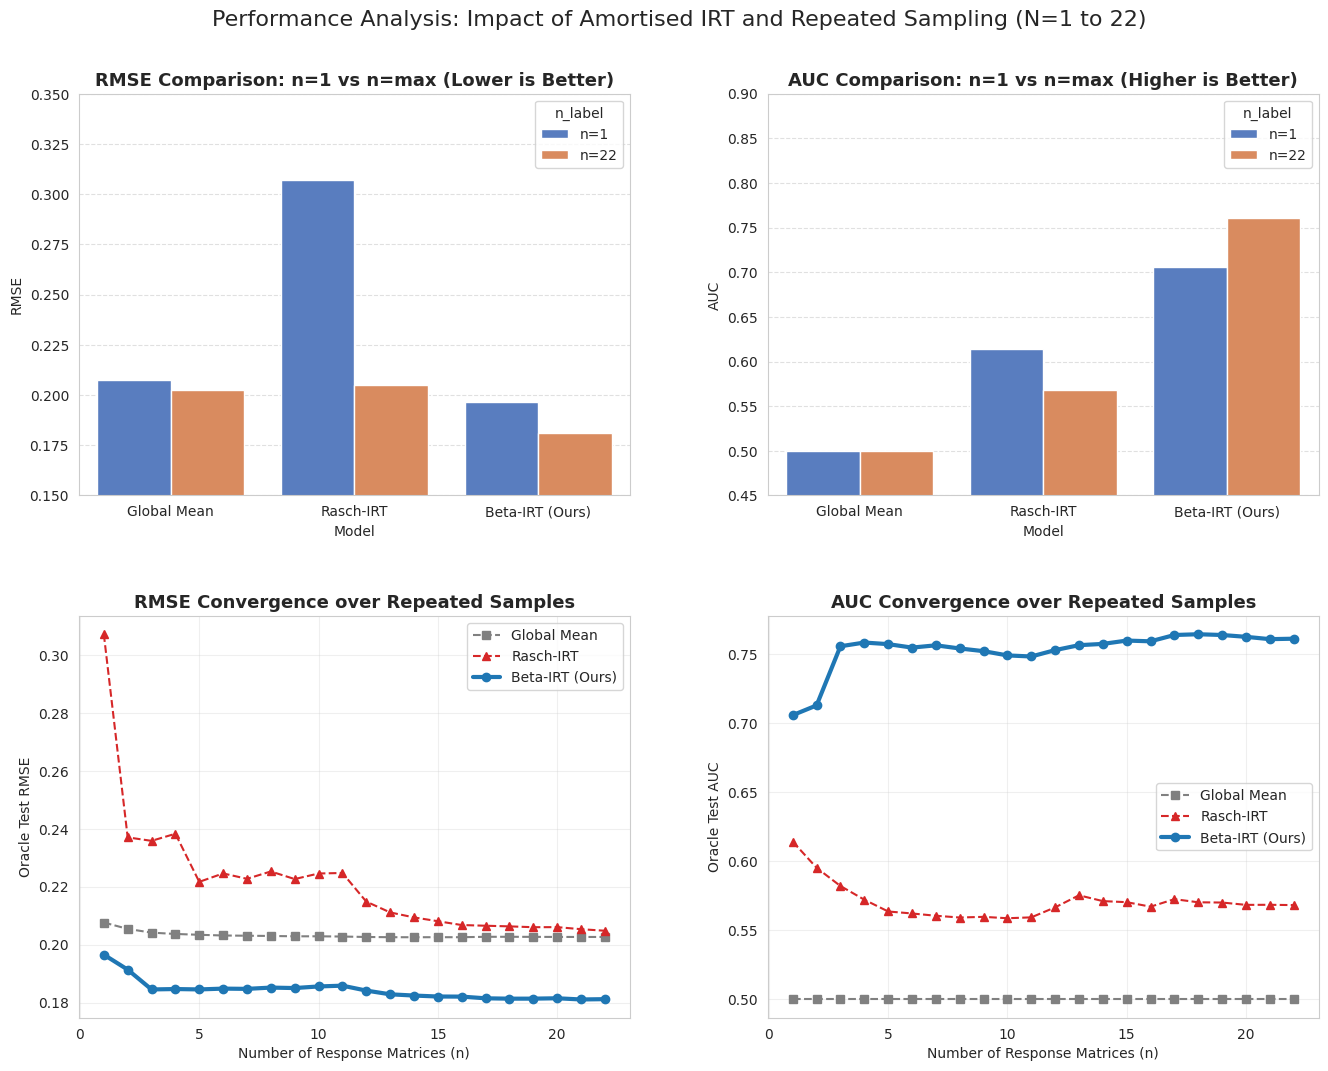

Visualization saved to 'plots/sampling_novelty_analysis.pdf'


In [4]:
# ==========================================================================
# ADVANCED VISUALIZATION: MODEL COMPARISON & SAMPLING NOVELTY
# ==========================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Prepare the full dataframe
df_full = pd.DataFrame(results)
n_max = df_full['n_samples'].max()

# 2. Extract start (n=1) and end (n=max) points for comparison
df_comp = df_full[df_full['n_samples'].isin([1, n_max])].copy()
df_comp['n_label'] = df_comp['n_samples'].apply(lambda x: f"n={x}")

# Melt data for easier plotting with Seaborn
rmse_melt = df_comp.melt(id_vars=['n_label'], value_vars=['rmse_mean', 'rmse_rasch', 'rmse_beta'], 
                        var_name='Model', value_name='RMSE')
auc_melt = df_comp.melt(id_vars=['n_label'], value_vars=['auc_mean', 'auc_rasch', 'auc_beta'], 
                       var_name='Model', value_name='AUC')

# Mapping for readable labels
model_map = {'rmse_mean': 'Global Mean', 'rmse_rasch': 'Rasch-IRT', 'rmse_beta': 'Beta-IRT (Ours)',
             'auc_mean': 'Global Mean', 'auc_rasch': 'Rasch-IRT', 'auc_beta': 'Beta-IRT (Ours)'}
rmse_melt['Model'] = rmse_melt['Model'].map(model_map)
auc_melt['Model'] = auc_melt['Model'].map(model_map)

# --- CREATE PLOTS ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
plt.subplots_adjust(hspace=0.3, wspace=0.25)

# A. RMSE Comparison (Bar)
sns.barplot(data=rmse_melt, x='Model', y='RMSE', hue='n_label', ax=axes[0, 0], palette="muted")
axes[0, 0].set_title('RMSE Comparison: n=1 vs n=max (Lower is Better)', fontsize=13, fontweight='bold')
axes[0, 0].set_ylim(0.15, 0.35)
axes[0, 0].grid(axis='y', linestyle='--', alpha=0.6)

# B. AUC Comparison (Bar)
sns.barplot(data=auc_melt, x='Model', y='AUC', hue='n_label', ax=axes[0, 1], palette="muted")
axes[0, 1].set_title('AUC Comparison: n=1 vs n=max (Higher is Better)', fontsize=13, fontweight='bold')
axes[0, 1].set_ylim(0.45, 0.9)
axes[0, 1].grid(axis='y', linestyle='--', alpha=0.6)

# C. RMSE Convergence Curve
axes[1, 0].plot(df_full['n_samples'], df_full['rmse_mean'], 's--', label='Global Mean', color='gray')
axes[1, 0].plot(df_full['n_samples'], df_full['rmse_rasch'], '^--', label='Rasch-IRT', color='tab:red')
axes[1, 0].plot(df_full['n_samples'], df_full['rmse_beta'], 'o-', label='Beta-IRT (Ours)', color='tab:blue', linewidth=3)
axes[1, 0].set_title('RMSE Convergence over Repeated Samples', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Number of Response Matrices (n)')
axes[1, 0].set_ylabel('Oracle Test RMSE')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# D. AUC Convergence Curve
axes[1, 1].plot(df_full['n_samples'], df_full['auc_mean'], 's--', label='Global Mean', color='gray')
axes[1, 1].plot(df_full['n_samples'], df_full['auc_rasch'], '^--', label='Rasch-IRT', color='tab:red')
axes[1, 1].plot(df_full['n_samples'], df_full['auc_beta'], 'o-', label='Beta-IRT (Ours)', color='tab:blue', linewidth=3)
axes[1, 1].set_title('AUC Convergence over Repeated Samples', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Number of Response Matrices (n)')
axes[1, 1].set_ylabel('Oracle Test AUC')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle(f"Performance Analysis: Impact of Amortised IRT and Repeated Sampling (N=1 to {n_max})", fontsize=16, y=.95)
plt.savefig('plots/sampling_novelty_analysis.pdf', bbox_inches='tight')
plt.show()

print(f"Visualization saved to 'plots/sampling_novelty_analysis.pdf'")